# 0 - préparation
installation et importacion des libréries nécessaires


In [36]:
%pip install matplotlib pulp ipywidgets IPython numpy networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
import random
import time
import matplotlib.pyplot as plt
from collections import deque
from pulp import *
from ipywidgets import IntProgress
from IPython.display import display
import statistics
import numpy as np
import copy
import networkx as nx
from matplotlib.lines import Line2D


# 1 - représentation du problème
La solution serat représenté par un liste avec la liste du chemin de chaque véhicule.

## 2.1 modélisation
#### fonction objectif
$$\text{Min } Z = \sum_{k=1}^{K} \sum_{i=0}^{n} \sum_{j=0}^{n} c_{ij} x_{ijk}$$
#### sous contraintes:
1. Unicité de visite :
$$\sum_{k=1}^{K} \sum_{i=1}^{n} x_{ijk} = 1 \quad \forall j \in \{1, \dots, n\}$$

2. Conservation du flux (Retour au dépôt) :
$$\sum_{i=0}^{n} x_{i0k} - \sum_{j=0}^{n} x_{0jk} = 0 \quad \forall k \in \{1, \dots, K\}$$

3. sous tour:
$$u_{jk} \geq u_{ik} + q_j - Q_{max}(1 - x_{ijk}) \quad \forall i, j \in \{1, \dots, n\}, i \neq j, \forall k$$

4. Capacité des véhicules :
$$ \sum_{i=0}^{n}\sum_{j=0}^{n} q_i \cdot x_{jik} \leq Q_{max} \quad \forall k \in \{1, \dots, K\}$$

5. Activation des véhicules :
$$\sum_{j=1}^{n} x_{0jk} \leq 1 \quad \forall k \in \{1, \dots, K\}$$

## 1.2 génerer des instances aléatoires

In [30]:
def generer_instance(n = None,nb_vehicules = None , n_max = 15,nb_vehicules_max = 10, max_capacite_coeff = 2.5):


    n = random.randint(5,n_max) if n is None else int(n)
    nb_vehicules = random.randint(2,nb_vehicules_max) if nb_vehicules is None else int(nb_vehicules)



    taille = n + 1
    matrice = [[0] * taille for _ in range(taille)]

    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5,50) if random.random() > 0.1 else float('inf')
            matrice[i][j] = dist
            matrice[j][i] = dist

    demandes = [0]
    total_colis = 0
    for _ in range(n):
        d = random.randint(1, 10)
        demandes.append(d)
        total_colis += d
    capacite_min = math.ceil(total_colis / nb_vehicules)
    capacite_max = int(capacite_min * random.uniform(1.1, max_capacite_coeff))

    print(f"\n--- Instance générée ---")
    print(f"Total colis à livrer : {total_colis}")
    print(f"Capacité par véhicule : {capacite_max}")

    return n, nb_vehicules, matrice, demandes, capacite_max

def distance_total(solution, matrice):
    """ Calcule la fonction objectif Z (Somme des distances) """
    z = 0
    for tournee in solution:

        for i in range(len(tournee) - 1):
            z += matrice[tournee[i]][tournee[i+1]]
    return z




def generer_random_solution(n, nb_vehicules, demandes, capacite_max):
    villes = list(range(1, n + 1))
    random.shuffle(villes)  # Mélange aléatoire des villes

    solution = []
    tournee_actuelle = [0] # On part du dépôt
    charge_actuelle = 0

    for ville in villes:
        demande_ville = demandes[ville]

        # Si on peut ajouter la ville dans le véhicule actuel
        if charge_actuelle + demande_ville <= capacite_max:
            tournee_actuelle.append(ville)
            charge_actuelle += demande_ville
        else:
            # Le véhicule est plein, on ferme la tournée et on rentre au dépôt
            tournee_actuelle.append(0)
            solution.append(tournee_actuelle)

            # On commence une nouvelle tournée avec la ville actuelle
            tournee_actuelle = [0, ville]
            charge_actuelle = demande_ville

    # Ne pas oublier de fermer la dernière tournée
    tournee_actuelle.append(0)
    solution.append(tournee_actuelle)

    # --- Gestion du nombre de véhicules ---
    # Si on a utilisé plus de véhicules que prévu
    if len(solution) > nb_vehicules:
        print(f"Attention : L'instance nécessite {len(solution)} véhicules, mais seulement {nb_vehicules} sont autorisés.")
        return None

    # Si on en a utilisé moins, on peut ajouter des tournées vides [0, 0]
    while len(solution) < nb_vehicules:
        solution.append([0, 0])

    return solution

def afficher_resultats(titre, solution, matrice, demandes, capacite_max):
    distance = distance_total(solution, matrice)
    print(f"\n{'='*15} {titre} {'='*15}")
    print(f"DISTANCE TOTALE : {distance}")
    print(f"VECTEUR SOLUTION : {solution}")
    print("-" * (32 + len(titre)))


    for k in range(len(solution)):
        route_actuelle = []
        charge_camion = 0

        for i in range(len(solution[k])):
            ville = solution[k][i]
            route_actuelle.append(ville)
            charge_camion += demandes[ville]

        print(f"Camion {k} [Charge {charge_camion}/{capacite_max}] : 0 -> {' -> '.join(map(str, route_actuelle))} -> 0")


## 1.3 verifier la solutions

In [4]:
def verifier_solution(solution, matrice, demandes, capacite_max):
    """
    Vérifie si une solution (liste de listes) respecte toutes les contraintes.
    """
    n = len(matrice) - 1
    villes_visitees = []

    for k, tournee in enumerate(solution):
        # --- Contrainte 5 : Activation du véhicule ---
        # On vérifie si le véhicule part du dépôt (sommet 0)
        if len(tournee) <= 2: # Une tournée vide ou juste [0,0]
            continue

        # --- Contrainte 2 : Conservation du flux (Départ et Retour Dépôt) ---
        if tournee[0] != 0 or tournee[-1] != 0:
            print(f"Erreur Véhicule {k} : Doit commencer et finir au dépôt (0).")
            return False

        charge_vehicule = 0
        for i in range(len(tournee) - 1):
            u = tournee[i]
            v = tournee[i+1]

            # --- Vérification de l'existence du trajet (Graphe) ---
            if matrice[u][v] == float('inf'):
                print(f"Erreur : Trajet impossible entre {u} et {v}.")
                return False

            # On suit les villes visitées (hors dépôt) pour l'unicité
            if v != 0:
                villes_visitees.append(v)
                charge_vehicule += demandes[v]

        # --- Contrainte 4 : Capacité des véhicules ---
        if charge_vehicule > capacite_max:
            print(f"Erreur Véhicule {k} : Capacité dépassée ({charge_vehicule} > {capacite_max}).")
            return False

    # --- Contrainte 1 : Unicité de visite ---
    # On vérifie si chaque ville {1..n} apparaît exactement une fois
    if sorted(villes_visitees) != list(range(1, n + 1)):
        print(f"Erreur : Les villes visitées {sorted(villes_visitees)} ne correspondent pas à la liste attendue.")
        return False

    return True



In [69]:
def visualiser_probleme(n, matrice, demandes, solution=None, titre="Visualisation CVRP"):
    G = nx.Graph()

    for i in range(n + 1):
        G.add_node(i)

    pos = nx.spring_layout(G)

    # --- Fond blanc garanti ---
    fig = plt.figure(figsize=(12, 8), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    plt.title(titre, fontweight='bold')

    labels_noeuds = {0: "Dépôt\n(q=0)"}
    for i in range(1, n + 1):
        labels_noeuds[i] = f"v{i}\n(q={demandes[i]})"

    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='firebrick', node_shape='s', node_size=2000)
    nx.draw_networkx_nodes(G, pos, nodelist=list(range(1, n+1)), node_color='teal', node_size=1500)

    nx.draw_networkx_labels(G, pos, labels=labels_noeuds, font_size=9, font_weight="bold", font_color='white')

    elements_legende = [
        Line2D([0], [0], marker='s', color='w', label='Dépôt', markerfacecolor='firebrick', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='Villes', markerfacecolor='teal', markersize=12)
    ]

    if solution:

        couleurs = [
            '#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4',
            '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324',
            '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075',
            '#a9a9a9', '#000000'
        ]
        etiquettes_aretes = {}

        for k, tournee in enumerate(solution):
            if len(tournee) <= 2:
                continue

            couleur_camion = couleurs[k % len(couleurs)]
            edges_tournee = []

            for i in range(len(tournee) - 1):
                u, v = tournee[i], tournee[i+1]
                if u != v:
                    edges_tournee.append((u, v))
                    etiquettes_aretes[(u, v)] = matrice[u][v]

            nx.draw_networkx_edges(
                G, pos,
                edgelist=edges_tournee,
                edge_color=couleur_camion,
                width=2.5,
                arrows=True,      # <-- CORRECTION DU WARNING ICI
                arrowstyle='->',
                arrowsize=20
            )

            elements_legende.append(Line2D([0], [0], color=couleur_camion, lw=2.5, label=f'Camion {k+1}'))

        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=etiquettes_aretes,
            font_color='red',
            font_size=10,
            font_weight='bold',
            label_pos=0.3,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
        )

    else:
        # === MODE RÉSEAU : On dessine tout le graphe ===
        edges_base = []
        etiquettes_base = {}

        for i in range(n + 1):
            # On commence à i+1 pour ne pas dessiner deux fois la même arête (aller et retour)
            for j in range(i + 1, n + 1):
                dist = matrice[i][j]
                if dist != 0 and dist != float('inf'):
                    edges_base.append((i, j))
                    etiquettes_base[(i, j)] = dist

        # On trace les lignes en gris clair et légèrement transparentes (alpha=0.3)
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges_base,
            edge_color='gray',
            width=1,
            alpha=0.3
        )

        # On ajoute les étiquettes de distance en gris
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=etiquettes_base,
            font_color='dimgray',
            font_size=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
        )

    plt.legend(
        handles=elements_legende,
        loc='upper left',
        facecolor='white',
        framealpha=1.0,
        edgecolor='black',
        fontsize=10,
        labelcolor='black'

    )

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 2 - résolutions

## 2.2 Résolution Algo tabu

## 2.3 résolution algo génétique
### 2.3.1 fonctions utils

In [19]:
def croisement(p1, p2, n, nb_vehicules, demandes, capacite_max,p_mutation = 0.1):
    # On extrait la liste des villes visitées dans l'ordre par les parents
    villes_p1 = [v for route in p1 for v in route if v != 0]
    villes_p2 = [v for route in p2 for v in route if v != 0]


    # Point de coupure aléatoire pour le croisement de listes
    cut = random.randint(1, n-1)
    enfant_villes = villes_p1[:cut]

    # Ajouter les villes du parent 2 non présentes
    for v in villes_p2:
        if v not in enfant_villes:
            enfant_villes.append(v)


    # mutations

    if random.random() < p_mutation: enfant_villes = muter_solution(enfant_villes)


    # Re-transformer cette liste de villes en solution valide (multi-routes)
    solution = []
    route = [0]
    charge = 0
    for v in enfant_villes:
        if charge + demandes[v] <= capacite_max:
            route.append(v)
            charge += demandes[v]
        else:
            route.append(0)
            solution.append(route)
            route = [0, v]
            charge = demandes[v]
    route.append(0)
    solution.append(route)
    while len(solution) < nb_vehicules: solution.append([0, 0])

    return solution

In [6]:
def muter_solution(solution_enfant):

    if len(solution_enfant) < 2: return solution_enfant

    i, j = random.sample(range(len(solution_enfant)), 2)
    solution_enfant[i], solution_enfant[j] = solution_enfant[j], solution_enfant[i]

    return solution_enfant

## 2.3.2 implémentation de l'alogrithme genetique

In [16]:
def algorithme_genetique(n, nb_vehicules, matrice, demandes, capacite_max, taille_pop=50, generations=100, p_mutation=0.1):
    # 1. Initialisation : Création de la population de départ
    population = []
    for _ in range(taille_pop):
        sol = generer_random_solution(n, nb_vehicules, demandes, capacite_max)
        if sol: population.append(sol)


    for gen in range(generations):
        # 2. Évaluation (Tri par fitness : la distance la plus courte en premier)
        population = sorted(population, key=lambda s: distance_total(s, matrice))

        nouvelle_population = population[:2] # On garde les 2 meilleurs (Élitisme)

        while len(nouvelle_population) < taille_pop:
            # 3. Sélection (Tournoi)
            parent1 = selection_tournoi(population, matrice)
            parent2 = selection_tournoi(population, matrice)

            # 4. Croisement (Crossover)
            enfant = croisement(parent1, parent2, n, nb_vehicules, demandes, capacite_max,p_mutation)


            if enfant: nouvelle_population.append(enfant)

        population = nouvelle_population
        if gen % 10 == 0:
            best_dist = distance_total(population[0], matrice)
            print(f"Génération {gen} : Meilleure distance = {best_dist}")

    return population[0]

def selection_tournoi(population, matrice, k=3):
    participants = random.sample(population, k)
    return min(participants, key=lambda s: distance_total(s, matrice))

## 2.3.3 Résultat

In [73]:

n, nb_vehicules, matrice, demandes, capacite_max = generer_instance()

s =algorithme_genetique(n, nb_vehicules, matrice, demandes, capacite_max)
afficher_resultats("algo genetique",s,matrice,demandes,capacite_max)

if verifier_solution(s,matrice, demandes, capacite_max):
    print("la solution est valide")
else:
    print("la solution est invalide")


--- Instance générée ---
Total colis à livrer : 67
Capacité par véhicule : 10
Attention : L'instance nécessite 10 véhicules, mais seulement 9 sont autorisés.
Attention : L'instance nécessite 10 véhicules, mais seulement 9 sont autorisés.
Attention : L'instance nécessite 10 véhicules, mais seulement 9 sont autorisés.
Génération 0 : Meilleure distance = inf
Génération 10 : Meilleure distance = inf
Génération 20 : Meilleure distance = inf
Génération 30 : Meilleure distance = inf
Génération 40 : Meilleure distance = inf
Génération 50 : Meilleure distance = inf
Génération 60 : Meilleure distance = inf
Génération 70 : Meilleure distance = inf
Génération 80 : Meilleure distance = inf
Génération 90 : Meilleure distance = inf

=============== algo genetique ===============
DISTANCE TOTALE : inf
VECTEUR SOLUTION : [[0, 4, 13, 0], [0, 6, 5, 0], [0, 1, 0], [0, 3, 8, 0], [0, 7, 0], [0, 11, 0], [0, 10, 9, 0], [0, 12, 2, 0], [0, 0]]
----------------------------------------------
Camion 0 [Charge 10/

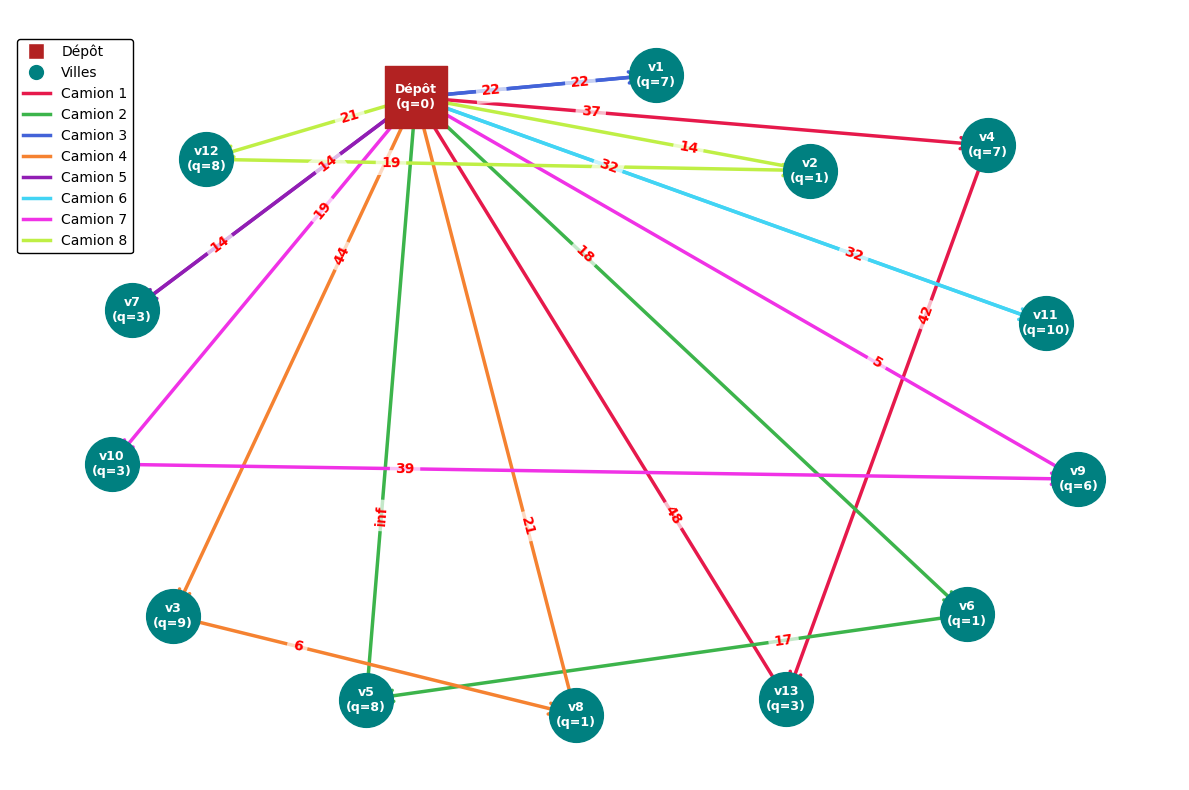

In [74]:
visualiser_probleme(n,matrice,demandes,s, titre="Visualisation CVRP")

## 2.4 résolution aglo marine

# 3 Comparaisons des algo
## 3.1 temps

## 3.2 précision

In [2]:
def voisinage(solution):
    for i in range(1, len(solution)):
        for j in range(i + 1, len(solution)):
            voisin = list(solution)
            voisin[i], voisin[j] = voisin[j], voisin[i]
            yield voisin

def recherche_tabou(solution_initiale, matrice_distances, demandes, capacite_max, taille_tabou, iter_max):
    nb_iter = 0
    liste_tabou = deque([], maxlen=taille_tabou)

    solution_courante = solution_initiale
    meilleure_globale = solution_initiale
    
    valeur_meilleure_globale = distance_total(solution_initiale, matrice_distances, demandes, capacite_max)

    while nb_iter < iter_max:
        valeur_meilleure_voisin = -1
        meilleure_voisin = None
        
        for voisin in voisinage(solution_courante):
            valeur_voisin = distance_total(voisin, matrice_distances, demandes, capacite_max)
            
            voisin_tuple = tuple(voisin)
            
            if voisin_tuple not in liste_tabou or valeur_voisin < valeur_meilleure_globale:
                if valeur_meilleure_voisin == -1 or valeur_voisin < valeur_meilleure_voisin:
                    valeur_meilleure_voisin = valeur_voisin
                    meilleure_voisin = voisin

        if meilleure_voisin is None:
            break

        solution_courante = meilleure_voisin
        liste_tabou.append(tuple(meilleure_voisin))

        if valeur_meilleure_voisin < valeur_meilleure_globale:
            meilleure_globale = meilleure_voisin
            valeur_meilleure_globale = valeur_meilleure_voisin
            nb_iter = 0
        else:
            nb_iter += 1

    return meilleure_globale

In [3]:

def recherche_tabou_traject(solution_initiale, matrice, demandes, capacite_max, taille_tabou, iter_max):
    nb_iter = 0
    liste_tabou = deque([], maxlen=taille_tabou)

    solution_courante = solution_initiale
    meilleure_globale = solution_initiale
    valeur_meilleure_globale = distance_total(solution_initiale, matrice, demandes, capacite_max)

    historique_courant = []
    historique_meilleur_global = []
    
    while nb_iter < iter_max:
        valeur_meilleure_voisin = -1
        meilleure_voisin = None
        
        for voisin in voisinage(solution_courante):
            val_v = distance_total(voisin, matrice, demandes, capacite_max)
            v_tuple = tuple(voisin)
            
            if v_tuple not in liste_tabou or val_v < valeur_meilleure_globale:
                if valeur_meilleure_voisin == -1 or val_v < valeur_meilleure_voisin:
                    valeur_meilleure_voisin = val_v
                    meilleure_voisin = voisin

        if meilleure_voisin is None:
            break

        solution_courante = meilleure_voisin
        liste_tabou.append(tuple(meilleure_voisin))

        if valeur_meilleure_voisin < valeur_meilleure_globale:
            meilleure_globale = meilleure_voisin
            valeur_meilleure_globale = valeur_meilleure_voisin
            nb_iter = 0
        else:
            nb_iter += 1
            
        val_pour_graph = valeur_meilleure_voisin if valeur_meilleure_voisin < 1000000 else 1000
        historique_courant.append(val_pour_graph)
        historique_meilleur_global.append(valeur_meilleure_globale)

    return meilleure_globale, historique_courant, historique_meilleur_global

In [4]:



n, nb_v, mat, dems, cap = generer_instance()

random.seed(a=3)
dist_min = -1
sol_best = None

for i in range(5):
    sol_depart = generer_random_solution(n, nb_v)
    
    solution_trouvee = recherche_tabou(sol_depart, mat, dems, cap, taille_tabou=10, iter_max=1000)
    val_actuelle = distance_total(solution_trouvee, mat, dems, cap)
    if val_actuelle == 1000000:
        print(f"Itération {i} : ECHEC (capacité dépassée)")
    else:
        print(f"Itération {i} : Distance = {val_actuelle}")
        
    if val_actuelle != 1000000:
        if dist_min == -1 or val_actuelle < dist_min:
            sol_best = solution_trouvee
            dist_min = val_actuelle
    
    if dist_min == -1 or val_actuelle < dist_min:
        sol_best = solution_trouvee
        dist_min = val_actuelle

afficher_resultats("MEILLEURE SOLUTION GLOBALE", sol_best, mat, dems, cap)

Combien de villes à livrer (hors dépôt) ? :  20
Combien de véhicules ? :  3



--- Instance générée ---
Total colis à livrer : 122
Capacité par véhicule : 48
Itération 0 : Distance = 235
Itération 1 : Distance = 222
Itération 2 : Distance = 242
Itération 3 : Distance = 263
Itération 4 : Distance = 266

=============== MEILLEURE SOLUTION GLOBALE ===============
DISTANCE TOTALE : 222
VECTEUR SOLUTION : [0, 3, 16, 11, 20, 6, 19, 0, 9, 10, 1, 18, 7, 17, 8, 0, 13, 4, 5, 2, 12, 15, 14]
----------------------------------------------------------
Camion 1 [Charge 48/48] : 0 -> 3 -> 16 -> 11 -> 20 -> 6 -> 19 -> 0
Camion 2 [Charge 40/48] : 0 -> 9 -> 10 -> 1 -> 18 -> 7 -> 17 -> 8 -> 0
Camion 3 [Charge 34/48] : 0 -> 13 -> 4 -> 5 -> 2 -> 12 -> 15 -> 14 -> 0


In [5]:
def afficher_courbe(courants, meilleurs_courants, title): 
    plt.figure(figsize=(10, 5))
    
    plt.plot(range(len(courants)), courants, label="Solution courante", color="tab:blue", alpha=0.7)
    plt.plot(range(len(meilleurs_courants)), meilleurs_courants, label="Meilleure solution", color="tab:orange", linewidth=2.5)
    
    plt.xlabel("Nombre d'itérations", fontsize=10)
    plt.ylabel("Valeur", fontsize=10)
    plt.title(title, fontsize=18)
    plt.legend()
    plt.grid(True)
    plt.show();

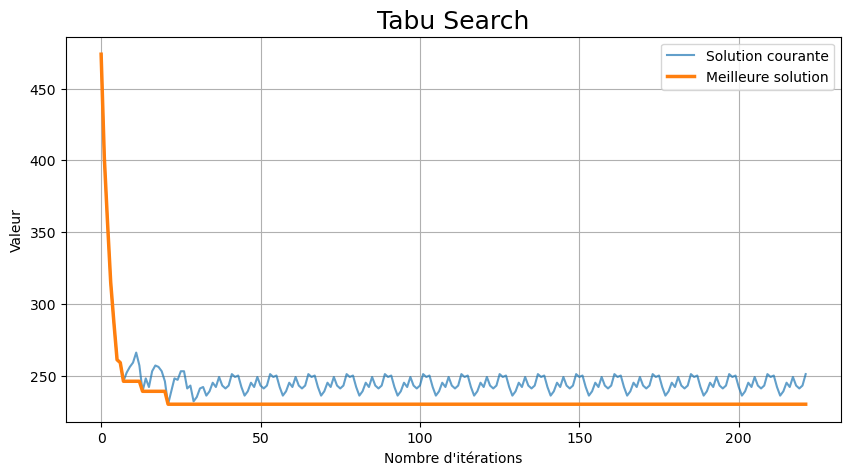

In [6]:
# Paramètres
iter_max = 200
taille_tabou = 10

val_depart = 1000000
while val_depart == 1000000:
    sol_initiale = generer_random_solution(n, nb_v)
    val_depart = distance_total(sol_initiale, mat, dems, cap)

sol_TS, courants_TS, meilleurs_courants_TS = recherche_tabou_traject(
    sol_initiale, mat, dems, cap, taille_tabou, iter_max
)

afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")

In [7]:
def borne_inferieure(matrice, demandes, capacite_max):
    n = len(matrice)
    villes = range(n)

    prob = LpProblem("CVRP_Lower_Bound", LpMinimize)

    x = LpVariable.dicts('route', (villes, villes), 0, 1, LpBinary)

    prob += lpSum([matrice[i][j] * x[i][j] for i in villes for j in villes if i != j])
    
    # Contrainte 1 : Chaque ville (sauf dépôt) doit être visitée une fois
    for j in range(1, n):
        prob += lpSum([x[i][j] for i in villes if i != j]) == 1
        prob += lpSum([x[j][i] for i in villes if i != j]) == 1
        
    # Contrainte 2 : Le dépôt doit voir sortir/entrer autant de véhicules que nécessaire
    prob += lpSum([x[0][j] for j in range(1, n)]) >= 1
    prob += lpSum([x[i][0] for i in range(1, n)]) >= 1

    prob.solve(PULP_CBC_CMD(msg=0))
    
    return value(prob.objective) if (LpStatus[prob.status] == "Optimal") else None

borne = borne_inferieure(mat, dems, cap)
valeur_actuelle = distance_total(sol_TS, mat, dems, cap)

print(f"Borne inférieure théorique : {borne}")
print(f"Valeur de ta solution Tabou : {valeur_actuelle}")

if borne:
    gap = ((valeur_actuelle - borne) / borne) * 100
    print(f"L'écart (GAP) est de : {gap:.2f}%")

Borne inférieure théorique : 159.0
Valeur de ta solution Tabou : 230
L'écart (GAP) est de : 44.65%


IntProgress(value=0, layout=Layout(width='100%'), max=50)

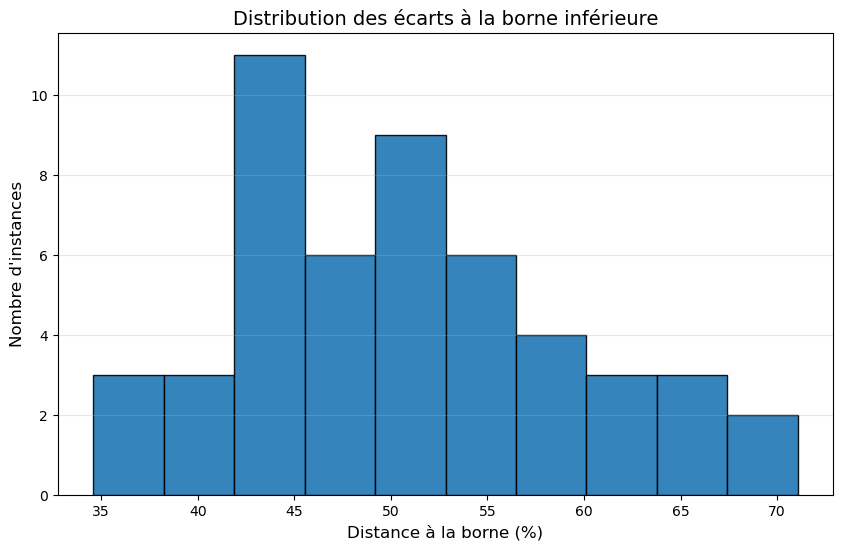

Moyenne du GAP sur 50 tests : 50.84%


In [8]:
gaps = deque(())
nb_tests = 50
iter_max = 100
taille_tabou = 10

bar = IntProgress(min=0, max=nb_tests, layout={"width" : "100%"})
display(bar)

for _ in range(nb_tests):
    borne = borne_inferieure(mat, dems, cap)

    val_depart = 1000000
    while val_depart == 1000000:
        solution_initiale = generer_random_solution(n, nb_v)
        val_depart = distance_total(solution_initiale, mat, dems, cap)

    sol_TS = recherche_tabou(solution_initiale, mat, dems, cap, taille_tabou, iter_max)
    val_finale = distance_total(sol_TS, mat, dems, cap)

    if borne and borne > 0:
        ecart = ((val_finale - borne) / borne) * 100
        gaps.append(ecart)
    
    bar.value += 1

bar.close()

if gaps:
    plt.figure(figsize=(10, 6))
    plt.hist(gaps, bins=10, edgecolor='black', alpha=0.9)
    
    plt.title("Distribution des écarts à la borne inférieure", fontsize=14)
    plt.xlabel("Distance à la borne (%)", fontsize=12)
    plt.ylabel("Nombre d'instances", fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.show();
    
    print(f"Moyenne du GAP sur {nb_tests} tests : {sum(gaps) / len(gaps):.2f}%")

IntProgress(value=0, layout=Layout(width='100%'), max=195)

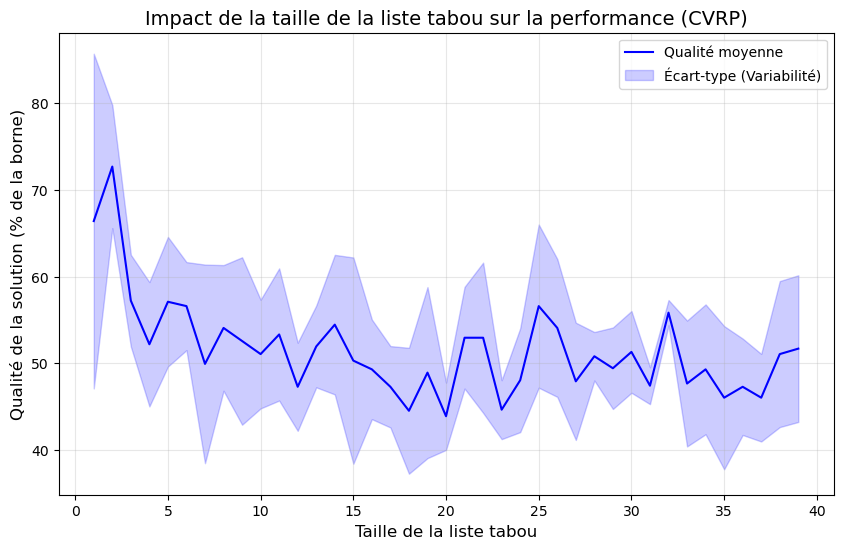

In [9]:
tabou_min = 1
tabou_max = 40
nb_test = 5    
iter_max = 50  

nb_steps_bar = (tabou_max - tabou_min) * nb_test
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

moyennes = []
deviations = []

for taille_tabou in range(tabou_min, tabou_max):
    resultats_taille = []

    for _ in range(nb_test):
        borne = borne_inferieure(mat, dems, cap)

        val_depart = 1000000
        while val_depart == 1000000:
            sol_init = generer_random_solution(n, nb_v)
            val_depart = distance_total(sol_init, mat, dems, cap)

        sol = recherche_tabou(sol_init, mat, dems, cap, taille_tabou, iter_max)
        
        val_sol = distance_total(sol, mat, dems, cap)
        score = ((val_sol - borne) / borne) * 100
        resultats_taille.append(score)
        
        bar.value += 1
        
    moyennes.append(statistics.mean(resultats_taille))
    deviations.append(np.std(resultats_taille))

bar.close()

plt.figure(figsize=(10, 6))

plt.plot(range(tabou_min, tabou_max), moyennes, label="Qualité moyenne", color="blue")

plt.fill_between(range(tabou_min, tabou_max), 
                 np.subtract(moyennes, deviations), 
                 np.add(moyennes, deviations), 
                 alpha=0.2, color="blue", label="Écart-type (Variabilité)")

plt.xlabel("Taille de la liste tabou", fontsize=12)
plt.ylabel("Qualité de la solution (% de la borne)", fontsize=12)
plt.title("Impact de la taille de la liste tabou sur la performance (CVRP)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();

IntProgress(value=0, layout=Layout(width='100%'))

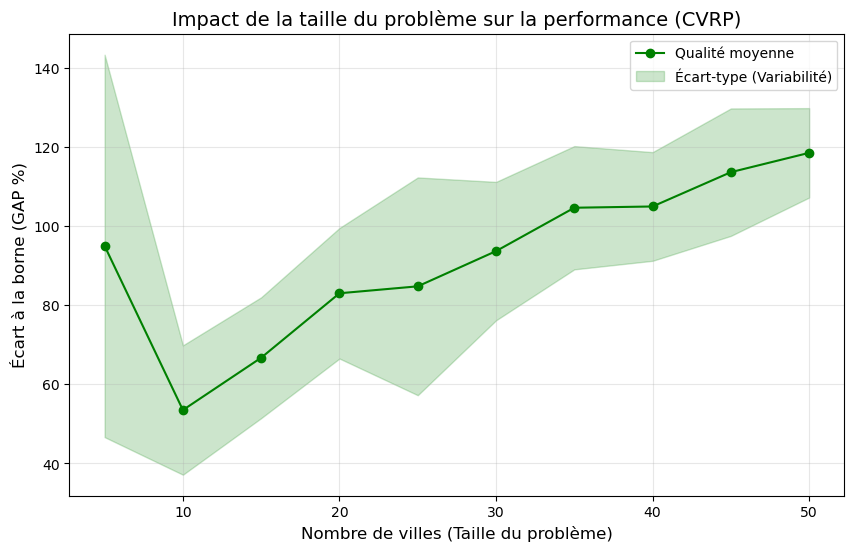

In [10]:
def generer_auto(n_villes, n_vehicules):
    taille = n_villes + 1
    matrice = [[0] * taille for _ in range(taille)]
    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5, 50)
            matrice[i][j] = matrice[j][i] = dist
    demandes = [0] + [random.randint(1, 10) for _ in range(n_villes)]
    capacite_max = int((sum(demandes) / n_vehicules) * 1.2)
    return n_villes, n_vehicules, matrice, demandes, capacite_max

villes_min   = 5
villes_max   = 55
villes_steps = 5
nb_test      = 10
taille_tabou = 15
iter_max     = 100

nb_steps_bar = ((villes_max - villes_min) / villes_steps) * nb_test
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

moyennes   = []
deviations = []

for n_villes in range(villes_min, villes_max, villes_steps):
    resultats_n = []
    
    for _ in range(nb_test):
        nb_v_t = max(2, n_villes // 5)
        n_t, nb_v_t, mat_t, dems_t, cap_t = generer_auto(n_villes, nb_v_t)
        
        borne = borne_inferieure(mat_t, dems_t, cap_t)

        val_depart = 1000000
        while val_depart == 1000000:
            sol_init = generer_random_solution(n_t, nb_v_t)
            val_depart = distance_total(sol_init, mat_t, dems_t, cap_t)

        sol = recherche_tabou(sol_init, mat_t, dems_t, cap_t, taille_tabou, iter_max)
        val_sol = distance_total(sol, mat_t, dems_t, cap_t)

        if borne and borne > 0:
            score = ((val_sol - borne) / borne) * 100
            resultats_n.append(score)
        
        bar.value += 1
        
    moyennes.append(statistics.mean(resultats_n))
    deviations.append(np.std(resultats_n))

bar.close()

plt.figure(figsize=(10, 6))

plt.plot(range(villes_min, villes_max, villes_steps), moyennes, label="Qualité moyenne", color="green", marker='o')

plt.fill_between(range(villes_min, villes_max, villes_steps),
                 np.subtract(moyennes, deviations),
                 np.add(moyennes, deviations),
                 alpha=0.2, color="green", label="Écart-type (Variabilité)")

plt.xlabel("Nombre de villes (Taille du problème)", fontsize=12)
plt.ylabel("Écart à la borne (GAP %)", fontsize=12)
plt.title("Impact de la taille du problème sur la performance (CVRP)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();